In [ ]:
# ==========================================
# CELL #0 - THE MASTER SETUP CELL (RUN THIS EVERY DAY)
# ==========================================


print("🚀 IGNITING MASTER SETUP PIPELINE...\n")

# ------------------------------------------
# 1. IMPORTS & LIBRARIES
# ------------------------------------------
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121, MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Concatenate
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

print("✅ Libraries Loaded.")

# ------------------------------------------
# 2. DATA GENERATORS & AUGMENTATION
# ------------------------------------------
IMG_SIZE = (224, 224) 
BATCH_SIZE = 16       

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("\n⚙️ Loading Images from Hard Drive...")
train_generator = train_datagen.flow_from_directory(
    r"D:\MasterDataset\train", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True)
val_generator = val_test_datagen.flow_from_directory(
    r"D:\MasterDataset\val", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_generator = val_test_datagen.flow_from_directory(
    r"D:\MasterDataset\test", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

print("✅ Data Generators Active.")

# ------------------------------------------
# 3. CLASS WEIGHTS (IMBALANCE FIX)
# ------------------------------------------
print("\n⚖️ Calculating mathematical class weights...")
train_classes = train_generator.classes
class_indices = train_generator.class_indices

class_weights_array = compute_class_weight('balanced', classes=np.unique(train_classes), y=train_classes)
class_weight_dict = dict(enumerate(class_weights_array))

print("✅ Class Weights Applied in RAM.")
print("\n🔥 MASTER PIPELINE READY! YOU ARE CLEAR TO TRAIN. 🔥")

Physical devices cannot be modified after being initialized
🚀 IGNITING MASTER SETUP PIPELINE...

✅ Libraries Loaded.

⚙️ Loading Images from Hard Drive...
Found 4581 images belonging to 15 classes.
Found 978 images belonging to 15 classes.
Found 992 images belonging to 15 classes.
✅ Data Generators Active.

⚖️ Calculating mathematical class weights...
✅ Class Weights Applied in RAM.

🔥 MASTER PIPELINE READY! YOU ARE CLEAR TO TRAIN. 🔥


In [15]:
import tensorflow as tf

# 1. Ask TF how many GPUs it can see
gpus = tf.config.list_physical_devices('GPU')
print(f"Num GPUs Available: {len(gpus)}")

# 2. Print the exact name of the graphics card it found
if gpus:
    for i, gpu in enumerate(gpus):
        print(f"GPU {i}: {gpu.name}")
        
        # Optional: Set memory growth so TF doesn't hog all 4GB at once and crash
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
            print("✅ Memory growth successfully enabled.")
        except RuntimeError as e:
            print(e)
else:
    print("❌ WARNING: TensorFlow is using the CPU!")

Num GPUs Available: 1
GPU 0: /physical_device:GPU:0
Physical devices cannot be modified after being initialized


✅ Found 15 total disease classes.



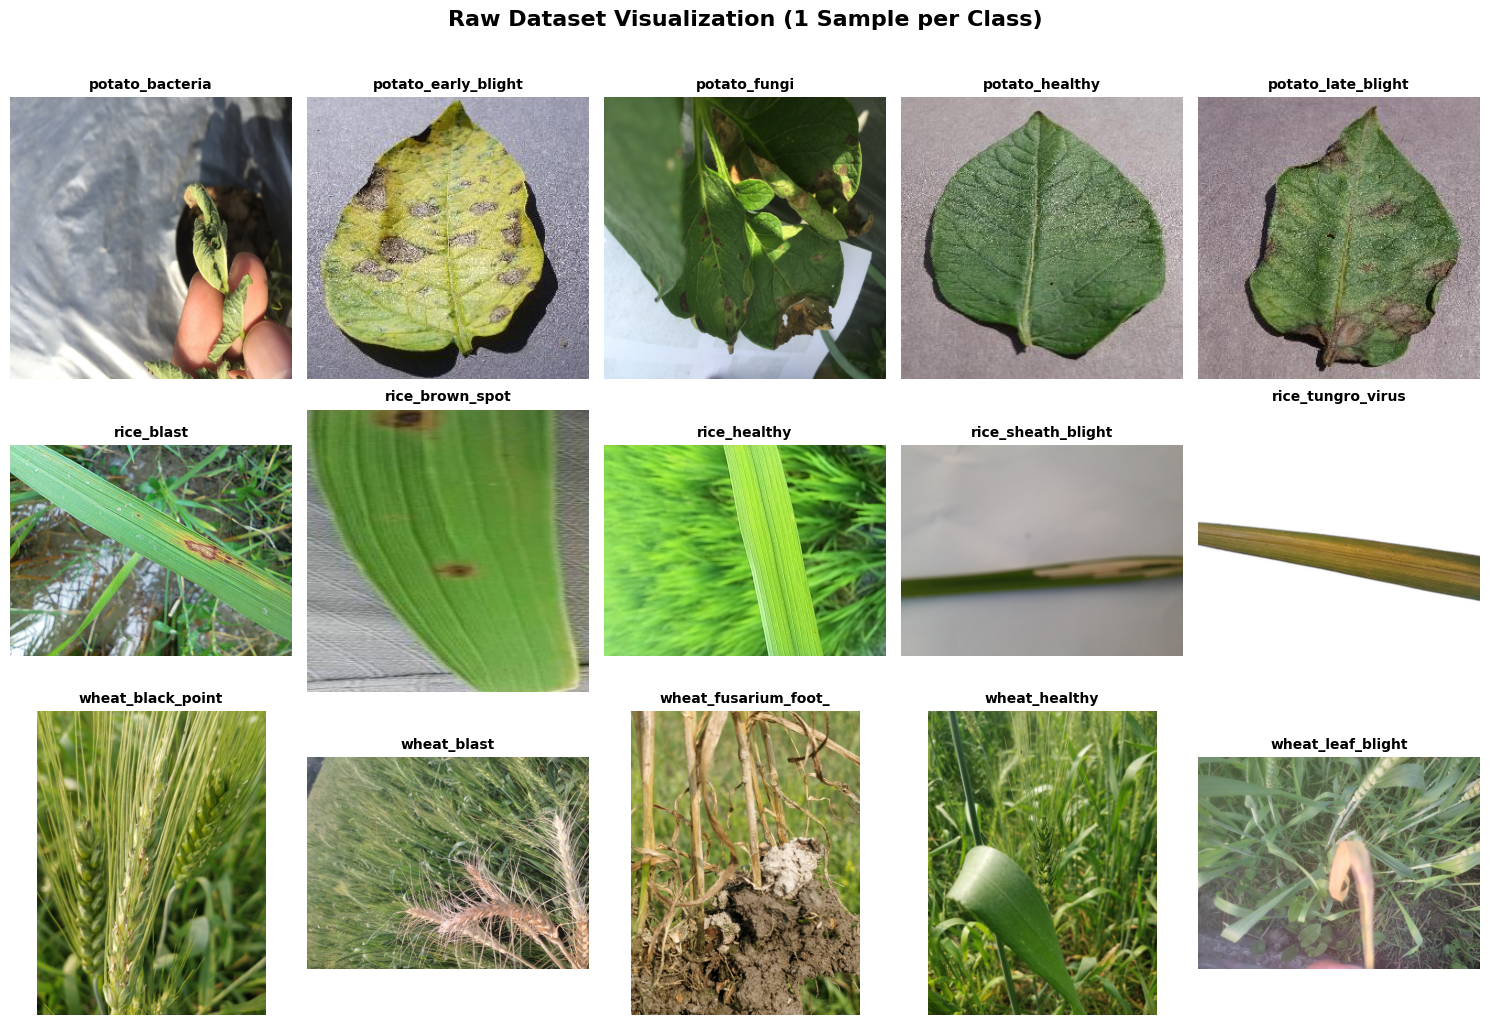

In [3]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. Define your exact local path
DATASET_PATH = r"D:\00"

# 2. Get all the disease class names (the subfolders)
classes = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))]
classes.sort() # Keep them in alphabetical order

# 3. Quick Data Sanity Check
print(f"✅ Found {len(classes)} total disease classes.\n")

# 4. Set up a beautiful plot (3 rows, 5 columns to fit 15 classes)
plt.figure(figsize=(15, 10))
num_to_show = min(15, len(classes))

for i in range(num_to_show):
    class_name = classes[i]
    class_dir = os.path.join(DATASET_PATH, class_name)
    
    # Get all images in this specific folder
    images = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg', '.JPG'))]
    
    if images:
        # Pick one random image to display
        img_name = random.choice(images)
        img_path = os.path.join(class_dir, img_name)
        
        # Read and plot
        img = mpimg.imread(img_path)
        plt.subplot(3, 5, i + 1) 
        plt.imshow(img)
        
        # Add the class name as the title, cut it short if it's too long
        plt.title(class_name[:20], fontsize=10, fontweight='bold')
        plt.axis('off')

# Display the master grid
plt.suptitle("Raw Dataset Visualization (1 Sample per Class)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
import os
import random
import shutil

# 1. Define paths
SRC_DIR = r"D:\00"
DEST_DIR = r"D:\MasterDataset"

# 2. Define split ratios (Change these if your thesis used 80/10/10)
train_ratio = 0.70
val_ratio = 0.15
# The test set will automatically take whatever is left (15%)

print(f"🚀 Starting Data Split (Train: {train_ratio*100}%, Val: {val_ratio*100}%, Test: {round((1-train_ratio-val_ratio)*100, 1)}%)...")
print(f"Source: {SRC_DIR}")
print(f"Destination: {DEST_DIR}\n")

# 3. Create the main destination folders
for split in ['train', 'val', 'test']:
    split_dir = os.path.join(DEST_DIR, split)
    os.makedirs(split_dir, exist_ok=True)

# Trackers for your Thesis Book reporting
total_images = 0
total_train = 0
total_val = 0
total_test = 0

# Get all the classes again
classes = [d for d in os.listdir(SRC_DIR) if os.path.isdir(os.path.join(SRC_DIR, d))]

for class_name in classes:
    src_class_dir = os.path.join(SRC_DIR, class_name)
    
    # Create the 15 class subdirectories inside train, val, and test
    os.makedirs(os.path.join(DEST_DIR, 'train', class_name), exist_ok=True)
    os.makedirs(os.path.join(DEST_DIR, 'val', class_name), exist_ok=True)
    os.makedirs(os.path.join(DEST_DIR, 'test', class_name), exist_ok=True)
    
    # Get all images for this specific disease
    images = [f for f in os.listdir(src_class_dir) if f.endswith(('.jpg', '.png', '.jpeg', '.JPG'))]
    
    # SHUFFLE: We are going raw here. No seed! Every run is uniquely random.
    random.shuffle(images)
    
    # Calculate the exact cut-off points for the array
    num_images = len(images)
    train_end = int(num_images * train_ratio)
    val_end = train_end + int(num_images * val_ratio)
    
    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]
    
    # COPY files over (We use copy2 instead of move, so D:\00 stays safe as a backup)
    for img in train_images:
        shutil.copy2(os.path.join(src_class_dir, img), os.path.join(DEST_DIR, 'train', class_name, img))
    for img in val_images:
        shutil.copy2(os.path.join(src_class_dir, img), os.path.join(DEST_DIR, 'val', class_name, img))
    for img in test_images:
        shutil.copy2(os.path.join(src_class_dir, img), os.path.join(DEST_DIR, 'test', class_name, img))
        
    # Update our counters
    total_images += num_images
    total_train += len(train_images)
    total_val += len(val_images)
    total_test += len(test_images)

print("✅ Data Splitting Complete!\n")
print("📊 --- THESIS DATASET SUMMARY ---")
print(f"Total Images Processed: {total_images}")
print(f"📁 Train Set: {total_train} images ({round((total_train/total_images)*100, 1)}%)")
print(f"📁 Validation Set: {total_val} images ({round((total_val/total_images)*100, 1)}%)")
print(f"📁 Test Set: {total_test} images ({round((total_test/total_images)*100, 1)}%)")

🚀 Starting Data Split (Train: 70.0%, Val: 15.0%, Test: 15.0%)...
Source: D:\00
Destination: D:\MasterDataset

✅ Data Splitting Complete!

📊 --- THESIS DATASET SUMMARY ---
Total Images Processed: 6551
📁 Train Set: 4581 images (69.9%)
📁 Validation Set: 978 images (14.9%)
📁 Test Set: 992 images (15.1%)


📊 --- TRAINING DATA DISTRIBUTION ---
Total Training Images: 4581

rice_blast                     : 579 images (12.6%)
potato_fungi                   : 489 images (10.7%)
potato_healthy                 : 452 images (9.9%)
potato_bacteria                : 398 images (8.7%)
potato_early_blight            : 351 images (7.7%)
rice_sheath_blight             : 350 images (7.6%)
rice_brown_spot                : 296 images (6.5%)
wheat_blast                    : 280 images (6.1%)
wheat_leaf_blight              : 280 images (6.1%)
wheat_black_point              : 212 images (4.6%)
potato_late_blight             : 202 images (4.4%)
rice_healthy                   : 175 images (3.8%)
wheat_fusarium_foot_rot        : 175 images (3.8%)
wheat_healthy                  : 175 images (3.8%)
rice_tungro_virus              : 167 images (3.6%)


C:\Users\shiha\AppData\Local\Temp\ipykernel_12084\3701535544.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Image Count', y='Disease Class', data=df_counts, palette='viridis')


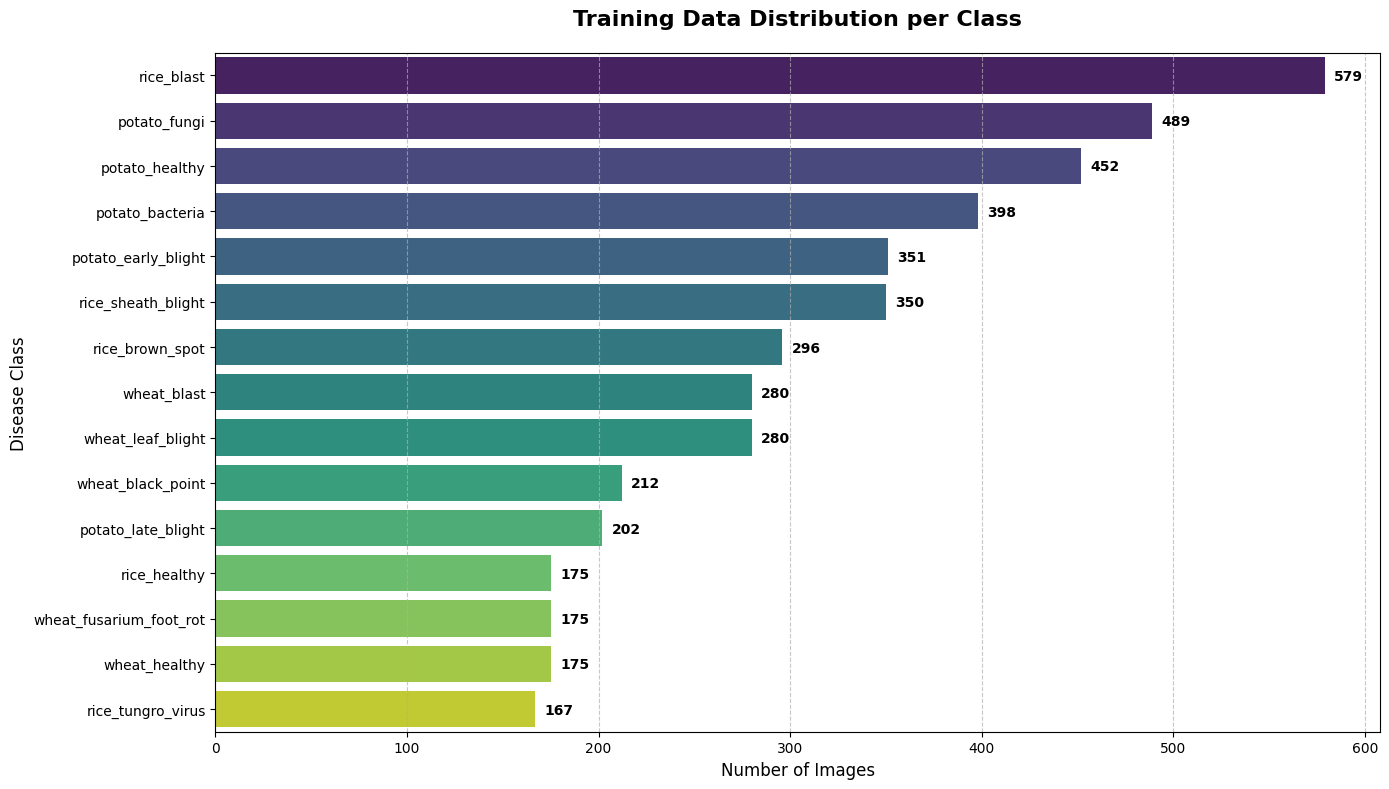

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the training directory
TRAIN_DIR = r"D:\MasterDataset\train"

# 2. Count images per class
class_counts = {}
for class_name in os.listdir(TRAIN_DIR):
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        count = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg', '.JPG'))])
        class_counts[class_name] = count

# 3. Convert to DataFrame for easy sorting
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Disease Class', 'Image Count'])
df_counts = df_counts.sort_values(by='Image Count', ascending=False).reset_index(drop=True)

# 4. Print the Text Output
print("📊 --- TRAINING DATA DISTRIBUTION ---")
total_train_images = df_counts['Image Count'].sum()
print(f"Total Training Images: {total_train_images}\n")

# Print each class with perfect alignment
for index, row in df_counts.iterrows():
    percentage = (row['Image Count'] / total_train_images) * 100
    # ljust(30) keeps the spacing clean even with long disease names
    print(f"{row['Disease Class'].ljust(30)} : {row['Image Count']} images ({percentage:.1f}%)")

# 5. Generate the Visual (Professional Bar Chart)
plt.figure(figsize=(14, 8))
sns.barplot(x='Image Count', y='Disease Class', data=df_counts, palette='viridis')

# Add values to the end of the bars
for i, v in enumerate(df_counts['Image Count']):
    plt.text(v + 5, i + 0.1, str(v), color='black', fontweight='bold')

plt.title('Training Data Distribution per Class', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Disease Class', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
# ==========================================
# CELL #6 - BUILDING DENSENET121
# ==========================================
print("🏗️ Building DenseNet121 Architecture...\n")

# 1. Create the MasterModels folder
MODELS_DIR = r"D:\MasterModels"
os.makedirs(MODELS_DIR, exist_ok=True)

# 2. Load pre-trained DenseNet121 (Without the final ImageNet classification layer)
densenet_base = DenseNet121(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# 3. FREEZE the base model (Protects your 4GB GPU!)
densenet_base.trainable = False

# 4. Build our custom top layers for the 15 crop diseases
x = densenet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x) # A little extra brain power
predictions = Dense(15, activation='softmax')(x) # 15 classes!

# 5. Assemble the final model
densenet_model = Model(inputs=densenet_base.input, outputs=predictions)

# 6. Compile the model
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ DenseNet121 Compiled and Ready.")
# This summary will show you that out of ~7 million parameters, we are only training about 260,000!
densenet_model.summary()

🏗️ Building DenseNet121 Architecture...

✅ DenseNet121 Compiled and Ready.
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d_2 (ZeroPadding2  (None, 230, 230, 3)  0          ['input_2[0][0]']                
 D)                                                                                               
                                                                                                  
 conv1/conv (Conv2D)            (None, 112, 112, 64  9408        ['zero_padding2d_2[0][0]']       
                 

In [18]:
# ==========================================
# CELL #7 - TRAINING DENSENET121
# ==========================================
print("🚀 Starting DenseNet121 Training...\n")

# 1. Setup the Checkpoint Path
checkpoint_path = os.path.join(MODELS_DIR, "DenseNet121_Base.h5")

# 2. Setup the Safety Nets
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

# 3. TRAIN! 
# Notice we are passing the class_weight_dict from Cell #0 to handle the imbalanced data!
history_densenet = densenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15, # Set to 15, but EarlyStopping will jump in if it finishes early
    class_weight=class_weight_dict,
    callbacks=callbacks
)

print(f"\n✅ Training Complete! Best DenseNet121 model securely saved to: {checkpoint_path}")

🚀 Starting DenseNet121 Training...

Epoch 1/15
287/287 [==============================] - ETA: 0s - loss: 0.6748 - accuracy: 0.7420
Epoch 1: val_accuracy improved from -inf to 0.85992, saving model to D:\MasterModels\DenseNet121_Base.h5
287/287 [==============================] - 148s 473ms/step - loss: 0.6748 - accuracy: 0.7420 - val_loss: 0.4455 - val_accuracy: 0.8599 - lr: 0.0010
Epoch 2/15
287/287 [==============================] - ETA: 0s - loss: 0.3441 - accuracy: 0.8642
Epoch 2: val_accuracy improved from 0.85992 to 0.87832, saving model to D:\MasterModels\DenseNet121_Base.h5
287/287 [==============================] - 118s 410ms/step - loss: 0.3441 - accuracy: 0.8642 - val_loss: 0.3527 - val_accuracy: 0.8783 - lr: 0.0010
Epoch 3/15
287/287 [==============================] - ETA: 0s - loss: 0.3001 - accuracy: 0.8762
Epoch 3: val_accuracy improved from 0.87832 to 0.90695, saving model to D:\MasterModels\DenseNet121_Base.h5
287/287 [==============================] - 161s 561ms/step 

📊 Generating DenseNet121 Evaluation Metrics...



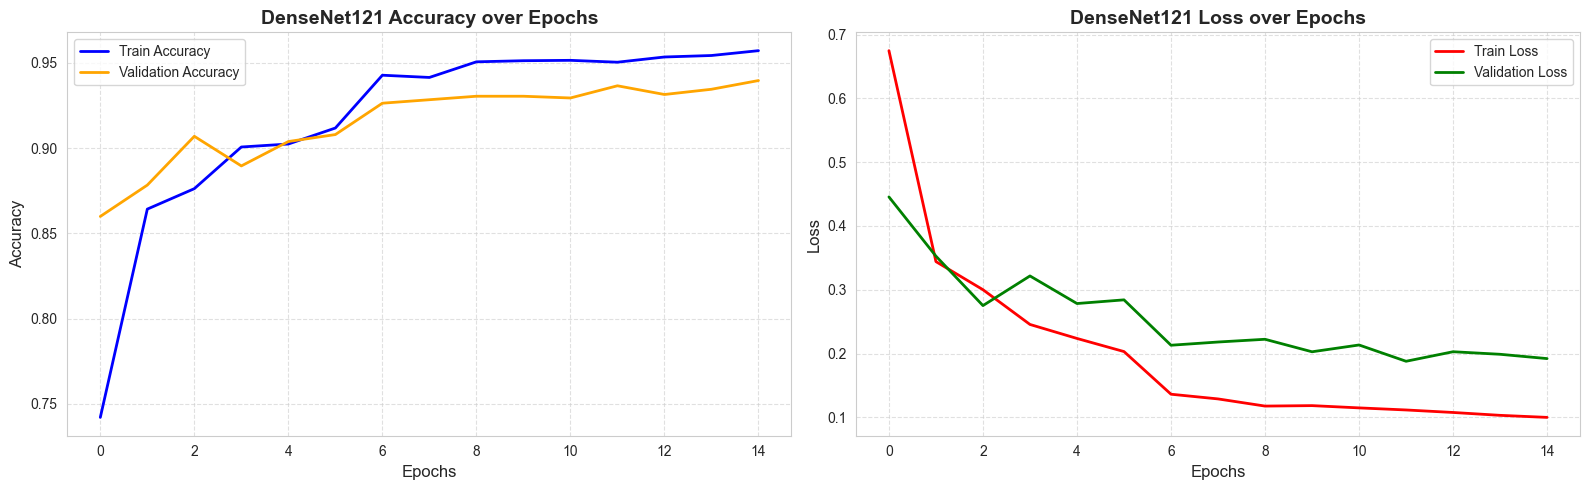


🔍 Running predictions on the unseen Test Set...
62/62 [==============================] - 43s 516ms/step

📄 --- CLASSIFICATION REPORT ---
                         precision    recall  f1-score   support

        potato_bacteria       0.95      0.94      0.95        86
    potato_early_blight       0.97      0.97      0.97        76
           potato_fungi       0.92      0.90      0.91       106
         potato_healthy       0.92      0.96      0.94        98
     potato_late_blight       0.95      0.95      0.95        44
             rice_blast       0.93      0.80      0.86       125
        rice_brown_spot       0.86      0.94      0.90        65
           rice_healthy       0.81      0.79      0.80        38
     rice_sheath_blight       0.89      0.89      0.89        75
      rice_tungro_virus       0.72      0.97      0.83        37
      wheat_black_point       0.94      1.00      0.97        46
            wheat_blast       1.00      1.00      1.00        60
wheat_fusarium_f

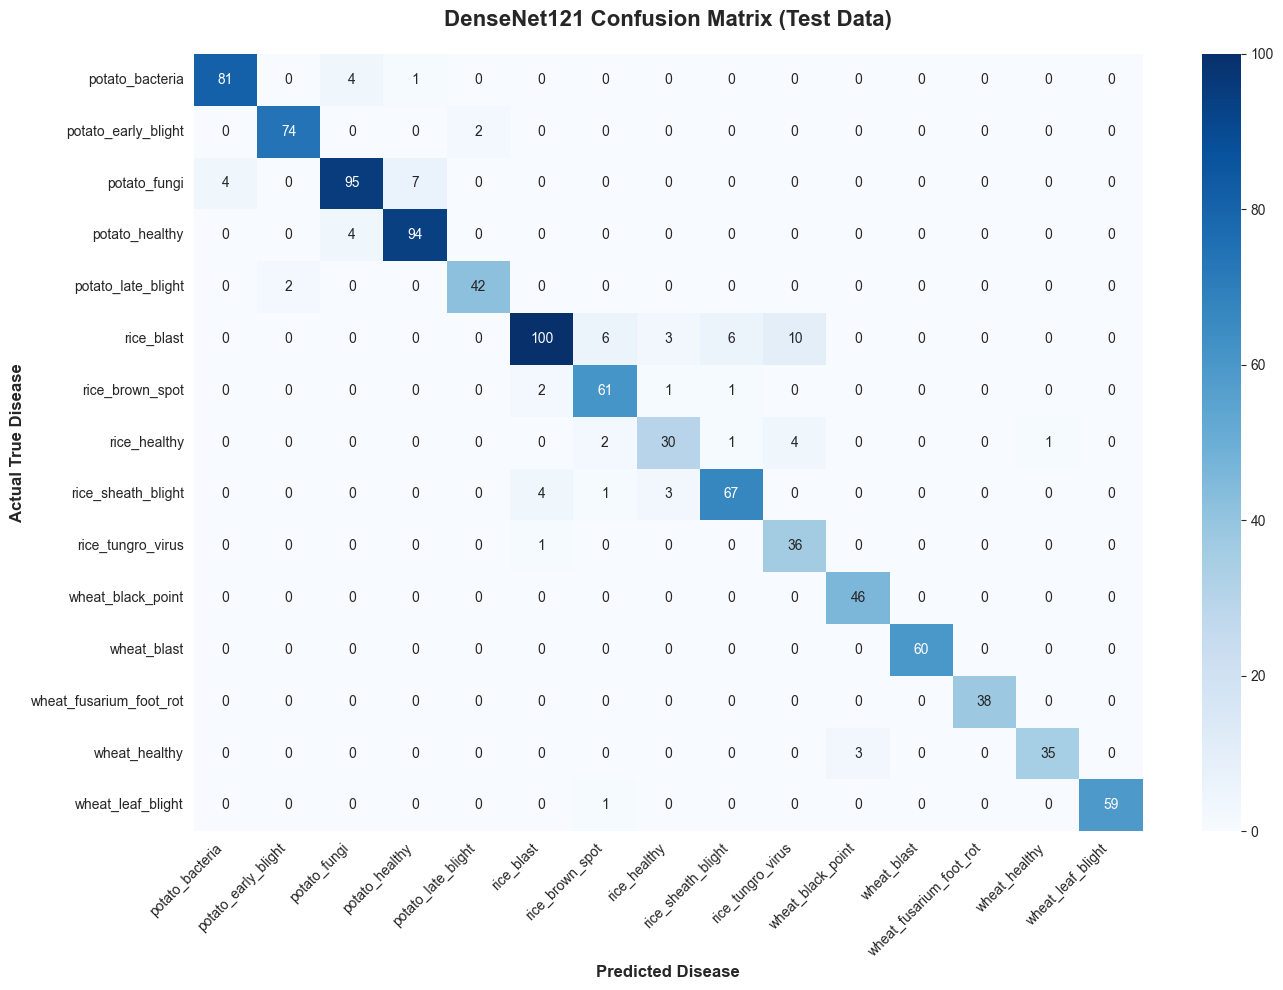

In [20]:
# ==========================================
# CELL #8 - DENSENET121 EVALUATION & VISUALS
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model

print("📊 Generating DenseNet121 Evaluation Metrics...\n")

# ------------------------------------------
# 1. PLOT TRAINING HISTORY (Accuracy & Loss)
# ------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy Plot
axes[0].plot(history_densenet.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
axes[0].plot(history_densenet.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
axes[0].set_title('DenseNet121 Accuracy over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Loss Plot
axes[1].plot(history_densenet.history['loss'], label='Train Loss', color='red', linewidth=2)
axes[1].plot(history_densenet.history['val_loss'], label='Validation Loss', color='green', linewidth=2)
axes[1].set_title('DenseNet121 Loss over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ------------------------------------------
# 2. PREDICT ON UNSEEN TEST DATA
# ------------------------------------------
# Load the absolute best weights saved by our Checkpoint callback
best_densenet = load_model(r"D:\MasterModels\DenseNet121_Base.h5")

print("\n🔍 Running predictions on the unseen Test Set...")
# We must reset the generator to ensure it reads from image #1 perfectly in order
test_generator.reset() 

# Predict! (verbose=1 shows a loading bar)
predictions = best_densenet.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

# Get the true answers and the names of the diseases
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# ------------------------------------------
# 3. TEXT REPORT: F1-SCORES
# ------------------------------------------
print("\n📄 --- CLASSIFICATION REPORT ---")
# This is the exact table you need to copy-paste into your thesis document!
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

# ------------------------------------------
# 4. VISUAL REPORT: CONFUSION MATRIX
# ------------------------------------------
print("\n🗺️ Generating Confusion Matrix Heatmap...")
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('DenseNet121 Confusion Matrix (Test Data)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Disease', fontsize=12, fontweight='bold')
plt.ylabel('Actual True Disease', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right') # Tilts the text so the long disease names fit
plt.tight_layout()
plt.show()

In [21]:
# ==========================================
# CELL #9 - BUILDING MOBILENETV2
# ==========================================
print("🏗️ Building MobileNetV2 Architecture...\n")

MODELS_DIR = r"D:\MasterModels"

# 1. Load pre-trained MobileNetV2 (Without the top layer)
mobilenet_base = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# 2. FREEZE the base model (Protecting the 4GB GPU!)
mobilenet_base.trainable = False

# 3. Build our custom top layers for the 15 classes
x = mobilenet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x) 
predictions = Dense(15, activation='softmax')(x) 

# 4. Assemble and Compile
mobilenet_model = Model(inputs=mobilenet_base.input, outputs=predictions)

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ MobileNetV2 Compiled and Ready.")
mobilenet_model.summary()

🏗️ Building MobileNetV2 Architecture...

✅ MobileNetV2 Compiled and Ready.
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_3[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                 

In [22]:
# ==========================================
# CELL #10 - TRAINING MOBILENETV2
# ==========================================
print("🚀 Starting MobileNetV2 Training...\n")

# 1. Setup the NEW Checkpoint Path
checkpoint_path_mobile = os.path.join(MODELS_DIR, "MobileNetV2_Base.h5")

# 2. Setup the Safety Nets
callbacks_mobile = [
    ModelCheckpoint(checkpoint_path_mobile, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

# 3. TRAIN! 
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15, 
    class_weight=class_weight_dict, 
    callbacks=callbacks_mobile
)

print(f"\n✅ Training Complete! Best MobileNetV2 model securely saved to: {checkpoint_path_mobile}")

🚀 Starting MobileNetV2 Training...

Epoch 1/15
287/287 [==============================] - ETA: 0s - loss: 0.6891 - accuracy: 0.7479
Epoch 1: val_accuracy improved from -inf to 0.83436, saving model to D:\MasterModels\MobileNetV2_Base.h5
287/287 [==============================] - 172s 575ms/step - loss: 0.6891 - accuracy: 0.7479 - val_loss: 0.4128 - val_accuracy: 0.8344 - lr: 0.0010
Epoch 2/15
287/287 [==============================] - ETA: 0s - loss: 0.3407 - accuracy: 0.8603
Epoch 2: val_accuracy improved from 0.83436 to 0.84356, saving model to D:\MasterModels\MobileNetV2_Base.h5
287/287 [==============================] - 155s 541ms/step - loss: 0.3407 - accuracy: 0.8603 - val_loss: 0.4457 - val_accuracy: 0.8436 - lr: 0.0010
Epoch 3/15
287/287 [==============================] - ETA: 0s - loss: 0.2803 - accuracy: 0.8832
Epoch 3: val_accuracy improved from 0.84356 to 0.89162, saving model to D:\MasterModels\MobileNetV2_Base.h5
287/287 [==============================] - 155s 538ms/step 

📊 Generating MobileNetV2 Evaluation Metrics...



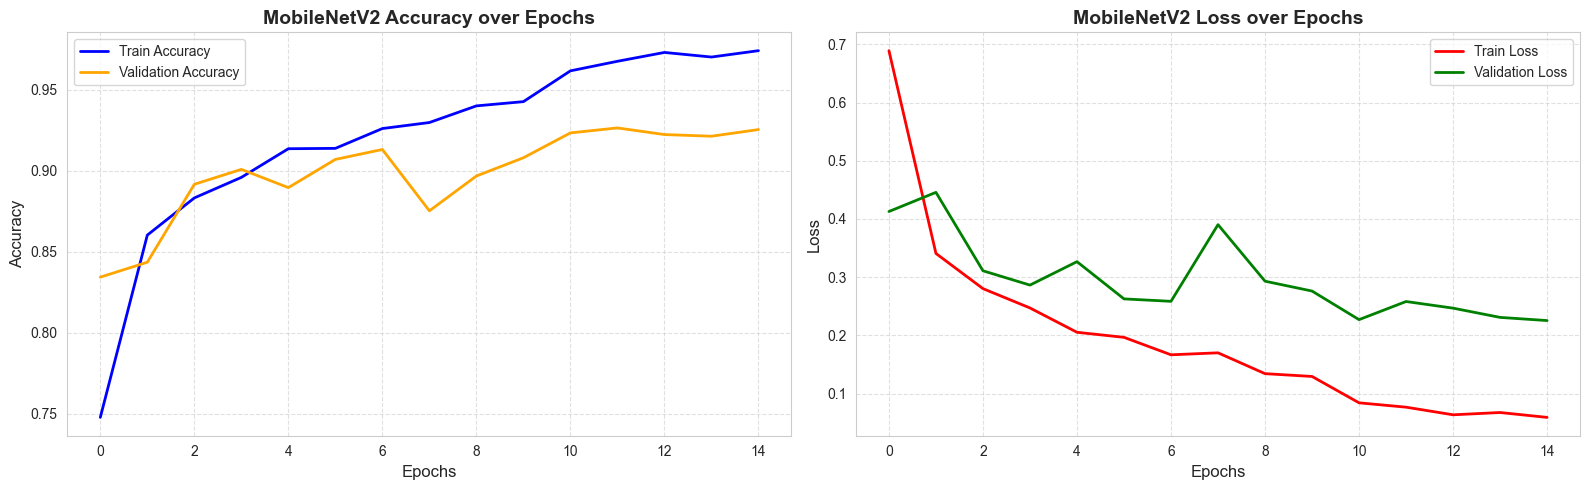


🔍 Running predictions on the unseen Test Set...
62/62 [==============================] - 20s 282ms/step

📄 --- MOBILENETV2 CLASSIFICATION REPORT ---
                         precision    recall  f1-score   support

        potato_bacteria       0.98      0.95      0.96        86
    potato_early_blight       1.00      0.97      0.99        76
           potato_fungi       0.90      0.97      0.93       106
         potato_healthy       0.99      0.89      0.94        98
     potato_late_blight       0.90      1.00      0.95        44
             rice_blast       0.89      0.80      0.84       125
        rice_brown_spot       0.89      0.83      0.86        65
           rice_healthy       0.76      0.92      0.83        38
     rice_sheath_blight       0.90      0.87      0.88        75
      rice_tungro_virus       0.79      1.00      0.88        37
      wheat_black_point       0.94      1.00      0.97        46
            wheat_blast       0.98      1.00      0.99        60
whea

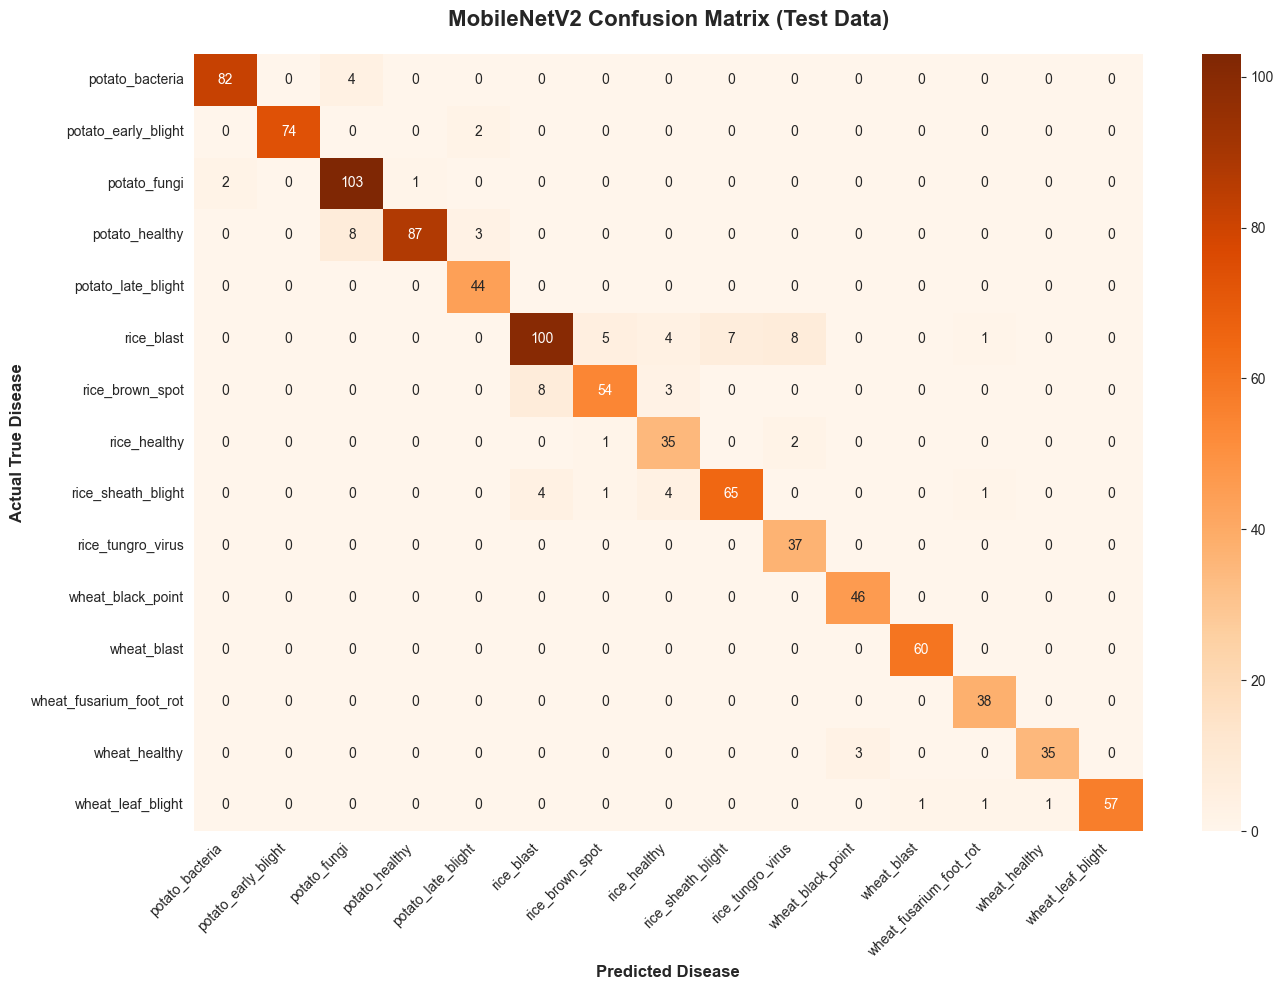

In [23]:
# ==========================================
# CELL #11 - MOBILENETV2 EVALUATION & VISUALS
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model

print("📊 Generating MobileNetV2 Evaluation Metrics...\n")

# ------------------------------------------
# 1. PLOT TRAINING HISTORY
# ------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy Plot
axes[0].plot(history_mobilenet.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
axes[0].plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
axes[0].set_title('MobileNetV2 Accuracy over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Loss Plot
axes[1].plot(history_mobilenet.history['loss'], label='Train Loss', color='red', linewidth=2)
axes[1].plot(history_mobilenet.history['val_loss'], label='Validation Loss', color='green', linewidth=2)
axes[1].set_title('MobileNetV2 Loss over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ------------------------------------------
# 2. PREDICT ON UNSEEN TEST DATA
# ------------------------------------------
# Load the absolute best weights from Epoch 12
best_mobilenet = load_model(r"D:\MasterModels\MobileNetV2_Base.h5")

print("\n🔍 Running predictions on the unseen Test Set...")
test_generator.reset() 

predictions_mobile = best_mobilenet.predict(test_generator, verbose=1)
predicted_classes_mobile = np.argmax(predictions_mobile, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# ------------------------------------------
# 3. TEXT REPORT: F1-SCORES
# ------------------------------------------
print("\n📄 --- MOBILENETV2 CLASSIFICATION REPORT ---")
report_mobile = classification_report(true_classes, predicted_classes_mobile, target_names=class_labels)
print(report_mobile)

# ------------------------------------------
# 4. VISUAL REPORT: CONFUSION MATRIX
# ------------------------------------------
print("\n🗺️ Generating Confusion Matrix Heatmap...")
cm_mobile = confusion_matrix(true_classes, predicted_classes_mobile)

plt.figure(figsize=(14, 10))
sns.heatmap(cm_mobile, annot=True, fmt='d', cmap='Oranges', xticklabels=class_labels, yticklabels=class_labels)
plt.title('MobileNetV2 Confusion Matrix (Test Data)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Disease', fontsize=12, fontweight='bold')
plt.ylabel('Actual True Disease', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [29]:
# ==========================================
# CELL #12 - BUILDING EFFICIENTNETB0
# ==========================================
print("🏗️ Building EfficientNetB0 Architecture...\n")

import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

MODELS_DIR = r"D:\MasterModels"

# 1. Load pre-trained EfficientNetB0 (Without the top layer)
efficientnet_base = EfficientNetB0(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# 2. Freeze the base model
efficientnet_base.trainable = False

# 3. Custom classifier
x = efficientnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
predictions = Dense(15, activation='softmax')(x)

# 4. Assemble model
efficientnet_model = Model(inputs=efficientnet_base.input, outputs=predictions)

# 5. Compile (LOWER LR for transfer learning)
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ EfficientNetB0 Compiled and Ready.")
efficientnet_model.summary()

🏗️ Building EfficientNetB0 Architecture...

✅ EfficientNetB0 Compiled and Ready.
Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling_2 (Rescaling)        (None, 224, 224, 3)  0           ['input_5[0][0]']                
                                                                                                  
 normalization_1 (Normalization  (None, 224, 224, 3)  7          ['rescaling_2[0][0]']            
 )                                                                                                
           

In [31]:
# ==========================================
# CELL #12 - BUILDING EFFICIENTNETB0
# ==========================================
print("🏗️ Building EfficientNetB0 Architecture...\n")

from tensorflow.keras.applications import EfficientNetB0

MODELS_DIR = r"D:\MasterModels"

# 1. Load pre-trained EfficientNetB0 (Without the top layer)
efficientnet_base = EfficientNetB0(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# 2. FREEZE the base model (Protecting the 4GB GPU!)
efficientnet_base.trainable = False

# 3. Build our custom top layers for the 15 classes
x = efficientnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x) 
predictions = Dense(15, activation='softmax')(x) 

# 4. Assemble and Compile
efficientnet_model = Model(inputs=efficientnet_base.input, outputs=predictions)

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ EfficientNetB0 Compiled and Ready.")
efficientnet_model.summary()

🏗️ Building EfficientNetB0 Architecture...

✅ EfficientNetB0 Compiled and Ready.
Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling_4 (Rescaling)        (None, 224, 224, 3)  0           ['input_6[0][0]']                
                                                                                                  
 normalization_2 (Normalization  (None, 224, 224, 3)  7          ['rescaling_4[0][0]']            
 )                                                                                                
           

In [32]:
print("🚀 Starting EfficientNetB0 Training...\n")

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# 🔥 Force safe class weights
class_weight_dict = {int(k): float(v) for k, v in class_weight_dict.items()}

# 🔥 FIXED checkpoint path
checkpoint_path_eff = os.path.join(MODELS_DIR, "EfficientNetB0_Base.keras")

callbacks_eff = [
    ModelCheckpoint(
        filepath=checkpoint_path_eff,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        save_weights_only=True,   # 💥 prevents JSON serialization crash
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history_efficientnet = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks_eff
)

print("\n✅ Training Complete!")

🚀 Starting EfficientNetB0 Training...

Epoch 1/15
287/287 [==============================] - ETA: 0s - loss: 2.7256 - accuracy: 0.0661
Epoch 1: val_accuracy improved from -inf to 0.08691, saving model to D:\MasterModels\EfficientNetB0_Base.keras
287/287 [==============================] - 177s 572ms/step - loss: 2.7256 - accuracy: 0.0661 - val_loss: 2.7074 - val_accuracy: 0.0869 - lr: 0.0010
Epoch 2/15
287/287 [==============================] - ETA: 0s - loss: 2.7085 - accuracy: 0.0642
Epoch 2: val_accuracy did not improve from 0.08691
287/287 [==============================] - 163s 568ms/step - loss: 2.7085 - accuracy: 0.0642 - val_loss: 2.7070 - val_accuracy: 0.0869 - lr: 0.0010
Epoch 3/15
287/287 [==============================] - ETA: 0s - loss: 2.7090 - accuracy: 0.0854
Epoch 3: val_accuracy did not improve from 0.08691
287/287 [==============================] - 155s 538ms/step - loss: 2.7090 - accuracy: 0.0854 - val_loss: 2.7078 - val_accuracy: 0.0869 - lr: 0.0010
Epoch 4/15
287/2